# Standardized Ingestion and OOD Retrieval Experiment

This notebook tests whether reducing preprocessing/domain differences helps FS2K out-of-distribution retrieval.

Experiment idea:

```text
raw/processed input -> standardized face crop -> neutral background -> retrieval training/eval
```

The goal is not to claim perfect background removal. With the current dependencies, the default pipeline uses deterministic PIL-based cropping, contrast normalization, and an oval face-region mask. 

## 1. Imports and configuration

In [1]:
from pathlib import Path
import os
import json
import math
import random
import re
import shutil
import time

os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'matplotlib'))

import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageEnhance, ImageFilter, ImageDraw

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path('/home/tndor/Documents/Work/Classwork/semester-4/main-challenge')
DATA_ROOT = PROJECT_ROOT / 'data'

SOURCE_CUFSF_DIR = DATA_ROOT / 'processed' / 'cufsf_224_gray'
SOURCE_CUFSF_PAIRS = SOURCE_CUFSF_DIR / 'pairs.csv'
SOURCE_FS2K_DIR = DATA_ROOT / 'FS2K'

PREVIOUS_OUTPUT_DIR = DATA_ROOT / 'outputs' / 'contrastive_resnet18_cufsf'
PREVIOUS_BEST_MODEL = PREVIOUS_OUTPUT_DIR / 'models' / 'best_resnet18_contrastive.pt'

OUTPUT_DIR = DATA_ROOT / 'outputs' / 'standardized_ingestion_ood'
STANDARDIZED_ROOT = DATA_ROOT / 'processed' / 'standardized_224_neutral'
STANDARDIZED_CUFSF_DIR = STANDARDIZED_ROOT / 'cufsf'
STANDARDIZED_FS2K_DIR = STANDARDIZED_ROOT / 'fs2k'
MODEL_DIR = OUTPUT_DIR / 'models'
FIGURE_DIR = OUTPUT_DIR / 'figures'
RETRIEVAL_DIR = OUTPUT_DIR / 'retrieval_examples'
for directory in [OUTPUT_DIR, STANDARDIZED_CUFSF_DIR, STANDARDIZED_FS2K_DIR, MODEL_DIR, FIGURE_DIR, RETRIEVAL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 224
BACKGROUND_VALUE = 238
FORCE_REPROCESS = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = 2
PIN_MEMORY = DEVICE == 'cuda'
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PROJECTION_DIM = 128
TEMPERATURE = 0.07
PATIENCE = 8
VAL_SELECTION_METRIC = 'MRR'

print('Device:', DEVICE)
print('Source CUFSF:', SOURCE_CUFSF_PAIRS, SOURCE_CUFSF_PAIRS.exists())
print('Source FS2K:', SOURCE_FS2K_DIR, SOURCE_FS2K_DIR.exists())
print('Standardized root:', STANDARDIZED_ROOT)

/home/tndor/Documents/Work/Classwork/semester-4/main-challenge/sketch2face/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
Source CUFSF: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/cufsf_224_gray/pairs.csv True
Source FS2K: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/FS2K True
Standardized root: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral


## 2. Load source pairs

This notebook reuses the frozen splits from the contrastive training notebook if they exist. That preserves comparability with the previous CUFSF result.

In [2]:
def audit_pairs(df, name):
    df = df.copy()
    df['id'] = df['id'].astype(str)
    if df['id'].str.fullmatch(r'\d+').all():
        df['id'] = df['id'].str.zfill(5)
    df['sketch_path'] = df['sketch_path'].astype(str)
    df['photo_path'] = df['photo_path'].astype(str)
    df['sketch_exists'] = df['sketch_path'].apply(lambda p: Path(p).exists())
    df['photo_exists'] = df['photo_path'].apply(lambda p: Path(p).exists())
    print(f'[{name}] rows:', len(df))
    print(f'[{name}] unique ids:', df['id'].nunique())
    print(f'[{name}] sketches exist:', int(df['sketch_exists'].sum()), '/', len(df))
    print(f'[{name}] photos exist:', int(df['photo_exists'].sum()), '/', len(df))
    assert df['sketch_exists'].all(), f'{name}: missing sketches'
    assert df['photo_exists'].all(), f'{name}: missing photos'
    return df.drop(columns=['sketch_exists', 'photo_exists'], errors='ignore')


def numeric_stem(path):
    match = re.search(r'(\d+)', Path(path).stem)
    return match.group(1) if match else None


def build_fs2k_pairs(fs2k_dir):
    rows = []
    for group_idx in [1, 2, 3]:
        photo_dir = fs2k_dir / 'photo' / f'photo{group_idx}'
        sketch_dir = fs2k_dir / 'sketch' / f'sketch{group_idx}'
        photos = {
            numeric_stem(p): p
            for p in photo_dir.iterdir()
            if p.suffix.lower() in {'.jpg', '.jpeg', '.png'} and numeric_stem(p)
        }
        sketches = {
            numeric_stem(p): p
            for p in sketch_dir.iterdir()
            if p.suffix.lower() in {'.jpg', '.jpeg', '.png'} and numeric_stem(p)
        }
        keys = sorted(set(photos) & set(sketches))
        print(f'FS2K group {group_idx}: {len(keys)} pairs')
        for key in keys:
            rows.append({
                'id': f'fs2k_{group_idx}_{key}',
                'dataset': 'FS2K',
                'group': group_idx,
                'sketch_path': str(sketches[key]),
                'photo_path': str(photos[key]),
            })
    return pd.DataFrame(rows).sort_values('id').reset_index(drop=True)


split_dir = PREVIOUS_OUTPUT_DIR / 'splits'
train_csv = split_dir / 'train_pairs.csv'
val_csv = split_dir / 'val_pairs.csv'
test_csv = split_dir / 'test_pairs.csv'

if train_csv.exists() and val_csv.exists() and test_csv.exists():
    train_df = pd.read_csv(train_csv, dtype={'id': str})
    val_df = pd.read_csv(val_csv, dtype={'id': str})
    test_df = pd.read_csv(test_csv, dtype={'id': str})
    print('Loaded previous frozen CUFSF splits.')
else:
    raise FileNotFoundError('Run notebook 02 first so the frozen train/val/test splits exist.')

fs2k_df = build_fs2k_pairs(SOURCE_FS2K_DIR)

train_df = audit_pairs(train_df, 'source CUFSF train')
val_df = audit_pairs(val_df, 'source CUFSF val')
test_df = audit_pairs(test_df, 'source CUFSF test')
fs2k_df = audit_pairs(fs2k_df, 'source FS2K')

print({'train': len(train_df), 'val': len(val_df), 'test': len(test_df), 'fs2k': len(fs2k_df)})

Loaded previous frozen CUFSF splits.
FS2K group 1: 1529 pairs
FS2K group 2: 98 pairs
FS2K group 3: 477 pairs
[source CUFSF train] rows: 764
[source CUFSF train] unique ids: 764
[source CUFSF train] sketches exist: 764 / 764
[source CUFSF train] photos exist: 764 / 764
[source CUFSF val] rows: 191
[source CUFSF val] unique ids: 191
[source CUFSF val] sketches exist: 191 / 191
[source CUFSF val] photos exist: 191 / 191
[source CUFSF test] rows: 239
[source CUFSF test] unique ids: 239
[source CUFSF test] sketches exist: 239 / 239
[source CUFSF test] photos exist: 239 / 239
[source FS2K] rows: 2104
[source FS2K] unique ids: 2104
[source FS2K] sketches exist: 2104 / 2104
[source FS2K] photos exist: 2104 / 2104
{'train': 764, 'val': 191, 'test': 239, 'fs2k': 2104}


## 3. Standardization functions

The default standardizer does four things:

1. Estimate the subject region.
2. Crop with consistent margins.
3. Resize to 224 x 224.
4. Put the face/subject area on a neutral background with contrast normalization.

For photos, OpenCV Haar detection is used if `cv2` is installed. Without OpenCV, the fallback uses a centered crop plus an oval mask. For sketches, the fallback uses content bounding boxes, which works better than face detection on line drawings.

OpenCV available: False


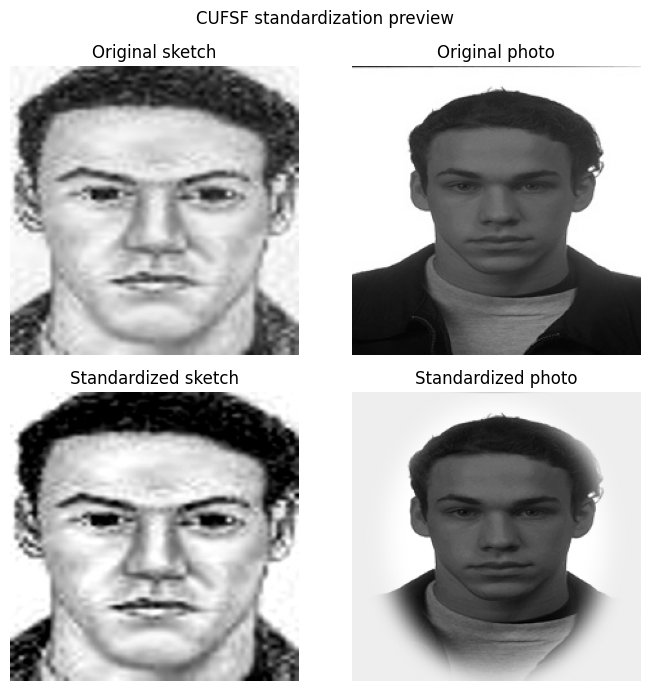

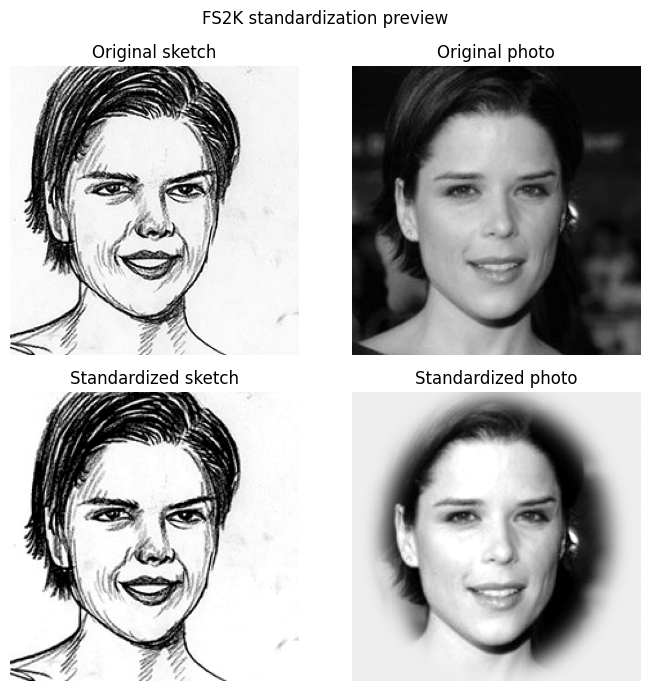

In [3]:
try:
    import cv2
    CV2_AVAILABLE = True
except Exception:
    cv2 = None
    CV2_AVAILABLE = False

print('OpenCV available:', CV2_AVAILABLE)


def content_bbox(gray, threshold=245, pad_ratio=0.18):
    arr = np.asarray(gray)
    mask = arr < threshold
    if mask.sum() < 50:
        return None
    ys, xs = np.where(mask)
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    w = x1 - x0 + 1
    h = y1 - y0 + 1
    pad = int(max(w, h) * pad_ratio)
    return (
        max(0, x0 - pad),
        max(0, y0 - pad),
        min(gray.width, x1 + pad),
        min(gray.height, y1 + pad),
    )


def cv2_face_bbox(rgb):
    if not CV2_AVAILABLE:
        return None
    arr = np.asarray(rgb)
    gray = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    detector = cv2.CascadeClassifier(cascade_path)
    faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=4, minSize=(40, 40))
    if len(faces) == 0:
        return None
    x, y, w, h = max(faces, key=lambda item: item[2] * item[3])
    cx = x + w / 2
    cy = y + h / 2
    side = max(w * 1.75, h * 2.05)
    x0 = int(max(0, cx - side / 2))
    y0 = int(max(0, cy - side * 0.45))
    x1 = int(min(rgb.width, cx + side / 2))
    y1 = int(min(rgb.height, y0 + side))
    return x0, y0, x1, y1


def square_crop_box(image, bbox=None):
    w, h = image.size
    if bbox is None:
        side = min(w, h)
        x0 = (w - side) // 2
        y0 = (h - side) // 2
        return x0, y0, x0 + side, y0 + side

    x0, y0, x1, y1 = bbox
    bw = x1 - x0
    bh = y1 - y0
    side = max(bw, bh)
    cx = (x0 + x1) / 2
    cy = (y0 + y1) / 2
    x0 = int(round(cx - side / 2))
    y0 = int(round(cy - side / 2))
    x1 = x0 + side
    y1 = y0 + side

    if x0 < 0:
        x1 -= x0
        x0 = 0
    if y0 < 0:
        y1 -= y0
        y0 = 0
    if x1 > w:
        x0 -= x1 - w
        x1 = w
    if y1 > h:
        y0 -= y1 - h
        y1 = h

    return max(0, x0), max(0, y0), min(w, x1), min(h, y1)


def oval_mask(size, blur=6, x_margin=0.14, y_margin=0.06):
    w, h = size
    mask = Image.new('L', size, 0)
    draw = ImageDraw.Draw(mask)
    box = (
        int(w * x_margin),
        int(h * y_margin),
        int(w * (1 - x_margin)),
        int(h * (1 - y_margin)),
    )
    draw.ellipse(box, fill=255)
    return mask.filter(ImageFilter.GaussianBlur(blur))


def standardize_image(path, kind, image_size=224, background_value=238):
    original = Image.open(path).convert('RGB')
    gray = ImageOps.grayscale(original)

    if kind == 'photo':
        bbox = cv2_face_bbox(original)
        if bbox is None:
            bbox = content_bbox(gray, threshold=245, pad_ratio=0.10)
    else:
        bbox = content_bbox(gray, threshold=245, pad_ratio=0.20)

    crop = original.crop(square_crop_box(original, bbox))
    crop = ImageOps.fit(crop, (image_size, image_size), method=Image.Resampling.BICUBIC, centering=(0.5, 0.45))
    crop_gray = ImageOps.grayscale(crop)
    crop_gray = ImageOps.autocontrast(crop_gray, cutoff=1)

    if kind == 'photo':
        crop_gray = ImageEnhance.Contrast(crop_gray).enhance(1.08)
        mask = oval_mask(crop_gray.size, blur=8, x_margin=0.12, y_margin=0.04)
        background = Image.new('L', crop_gray.size, background_value)
        standardized = Image.composite(crop_gray, background, mask)
    else:
        crop_gray = ImageEnhance.Contrast(crop_gray).enhance(1.15)
        standardized = crop_gray

    return standardized


def preview_standardization(row, title):
    fig, axes = plt.subplots(2, 2, figsize=(7, 7))
    sketch = Image.open(row['sketch_path']).convert('L')
    photo = Image.open(row['photo_path']).convert('L')
    sketch_std = standardize_image(row['sketch_path'], 'sketch')
    photo_std = standardize_image(row['photo_path'], 'photo')
    axes[0, 0].imshow(sketch, cmap='gray')
    axes[0, 0].set_title('Original sketch')
    axes[0, 1].imshow(photo, cmap='gray')
    axes[0, 1].set_title('Original photo')
    axes[1, 0].imshow(sketch_std, cmap='gray', vmin=0, vmax=255)
    axes[1, 0].set_title('Standardized sketch')
    axes[1, 1].imshow(photo_std, cmap='gray', vmin=0, vmax=255)
    axes[1, 1].set_title('Standardized photo')
    for ax in axes.ravel():
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

preview_standardization(train_df.sample(1, random_state=SEED).iloc[0], 'CUFSF standardization preview')
preview_standardization(fs2k_df.sample(1, random_state=SEED).iloc[0], 'FS2K standardization preview')

## 4. Write standardized image folders and pair CSVs

In [4]:
def safe_name(value):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(value))


def standardize_pairs(df, out_dir, name, force=False):
    sketch_dir = out_dir / 'sketches'
    photo_dir = out_dir / 'photos'
    sketch_dir.mkdir(parents=True, exist_ok=True)
    photo_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    for row in tqdm(df.to_dict('records'), desc=f'Standardizing {name}'):
        item_id = safe_name(row['id'])
        sketch_out = sketch_dir / f'{item_id}.png'
        photo_out = photo_dir / f'{item_id}.png'

        if force or not sketch_out.exists():
            standardize_image(row['sketch_path'], 'sketch', IMAGE_SIZE, BACKGROUND_VALUE).save(sketch_out)
        if force or not photo_out.exists():
            standardize_image(row['photo_path'], 'photo', IMAGE_SIZE, BACKGROUND_VALUE).save(photo_out)

        new_row = dict(row)
        new_row['source_sketch_path'] = row['sketch_path']
        new_row['source_photo_path'] = row['photo_path']
        new_row['sketch_path'] = str(sketch_out)
        new_row['photo_path'] = str(photo_out)
        new_row['standardization'] = '224_gray_neutral_oval_mask'
        rows.append(new_row)

    out_df = pd.DataFrame(rows)
    csv_path = out_dir / 'pairs.csv'
    out_df.to_csv(csv_path, index=False)
    print('Saved:', csv_path)
    return out_df


std_train_df = standardize_pairs(train_df, STANDARDIZED_CUFSF_DIR / 'train', 'CUFSF train', force=FORCE_REPROCESS)
std_val_df = standardize_pairs(val_df, STANDARDIZED_CUFSF_DIR / 'val', 'CUFSF val', force=FORCE_REPROCESS)
std_test_df = standardize_pairs(test_df, STANDARDIZED_CUFSF_DIR / 'test', 'CUFSF test', force=FORCE_REPROCESS)
std_fs2k_df = standardize_pairs(fs2k_df, STANDARDIZED_FS2K_DIR / 'all', 'FS2K all', force=FORCE_REPROCESS)

std_train_csv = STANDARDIZED_CUFSF_DIR / 'train_pairs.csv'
std_val_csv = STANDARDIZED_CUFSF_DIR / 'val_pairs.csv'
std_test_csv = STANDARDIZED_CUFSF_DIR / 'test_pairs.csv'
std_fs2k_csv = STANDARDIZED_FS2K_DIR / 'fs2k_pairs.csv'
std_train_df.to_csv(std_train_csv, index=False)
std_val_df.to_csv(std_val_csv, index=False)
std_test_df.to_csv(std_test_csv, index=False)
std_fs2k_df.to_csv(std_fs2k_csv, index=False)
print('Saved split CSVs:', std_train_csv, std_val_csv, std_test_csv, std_fs2k_csv)

Standardizing CUFSF train: 100%|██████████| 764/764 [00:06<00:00, 120.08it/s]


Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/cufsf/train/pairs.csv


Standardizing CUFSF val: 100%|██████████| 191/191 [00:01<00:00, 122.58it/s]


Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/cufsf/val/pairs.csv


Standardizing CUFSF test: 100%|██████████| 239/239 [00:01<00:00, 120.58it/s]


Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/cufsf/test/pairs.csv


Standardizing FS2K all: 100%|██████████| 2104/2104 [00:23<00:00, 89.77it/s] 


Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/fs2k/all/pairs.csv
Saved split CSVs: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/cufsf/train_pairs.csv /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/cufsf/val_pairs.csv /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/cufsf/test_pairs.csv /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/processed/standardized_224_neutral/fs2k/fs2k_pairs.csv


## 5. Visual audit of standardized pairs

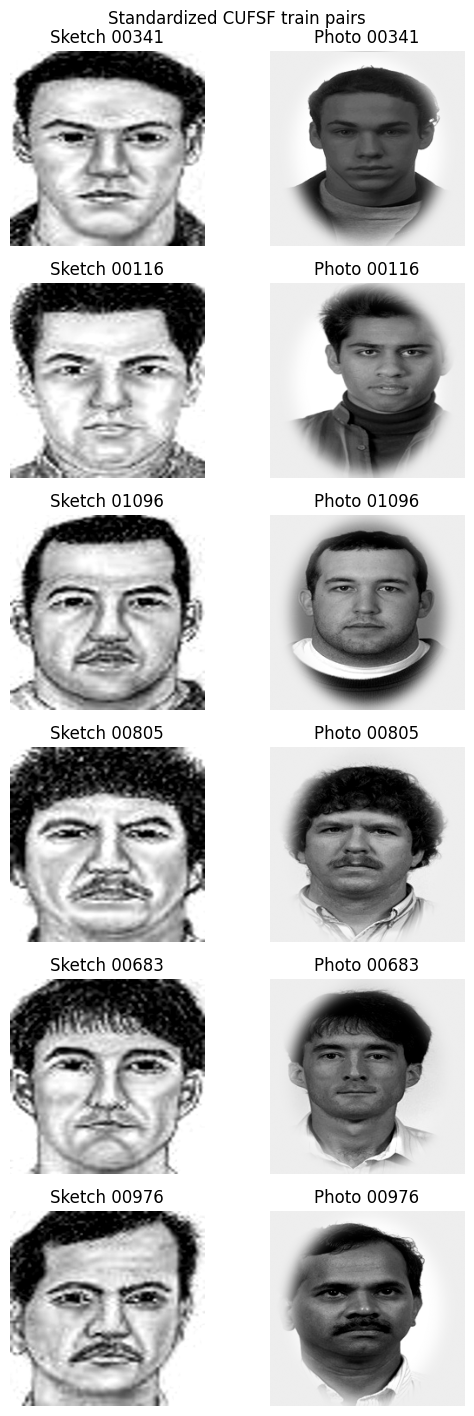

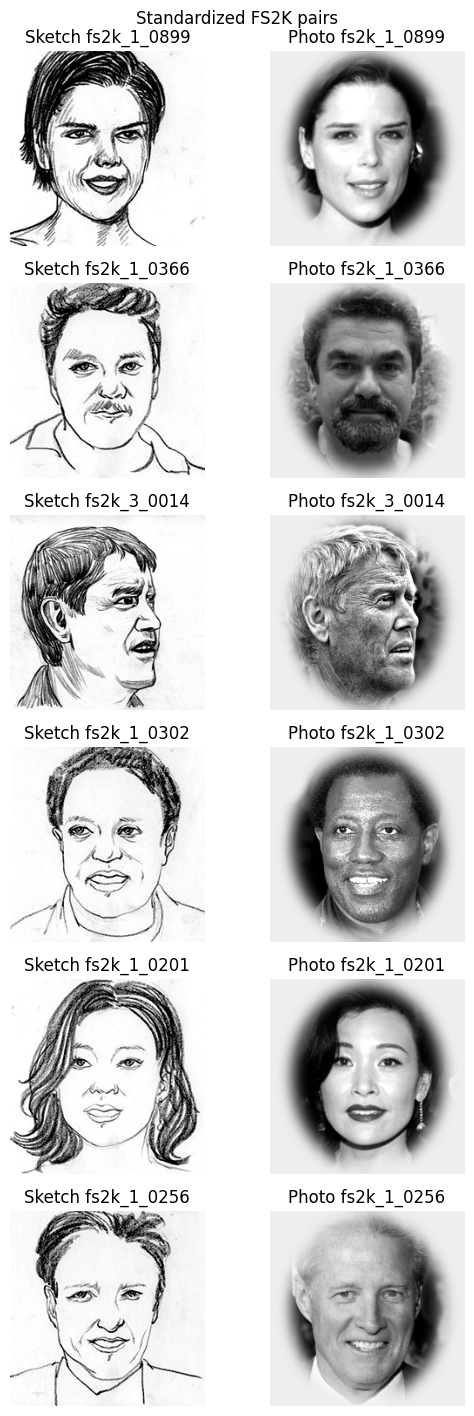

In [5]:
def show_pairs(df, n=6, seed=42, title='Pairs'):
    sample = df.sample(n=min(n, len(df)), random_state=seed).reset_index(drop=True)
    fig, axes = plt.subplots(len(sample), 2, figsize=(5.8, 2.4 * len(sample)))
    if len(sample) == 1:
        axes = np.array([axes])
    for i, row in sample.iterrows():
        sketch = Image.open(row['sketch_path']).convert('L')
        photo = Image.open(row['photo_path']).convert('L')
        axes[i, 0].imshow(sketch, cmap='gray', vmin=0, vmax=255)
        axes[i, 0].set_title(f"Sketch {row['id']}")
        axes[i, 0].axis('off')
        axes[i, 1].imshow(photo, cmap='gray', vmin=0, vmax=255)
        axes[i, 1].set_title(f"Photo {row['id']}")
        axes[i, 1].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_pairs(std_train_df, title='Standardized CUFSF train pairs')
show_pairs(std_fs2k_df, title='Standardized FS2K pairs')

## 6. Model, retrieval metrics, and loaders

These utilities mirror notebook 02 so this experiment can be run independently.

In [6]:
eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.10, contrast=0.10)], p=0.25),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class SketchPhotoPairDataset(Dataset):
    def __init__(self, pairs_df, transform):
        self.df = pairs_df.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sketch = Image.open(row['sketch_path']).convert('RGB')
        photo = Image.open(row['photo_path']).convert('RGB')
        return {
            'id': str(row['id']),
            'sketch': self.transform(sketch),
            'photo': self.transform(photo),
            'sketch_path': row['sketch_path'],
            'photo_path': row['photo_path'],
        }


class ResNet18ProjectionEncoder(nn.Module):
    def __init__(self, projection_dim=128, pretrained=True):
        super().__init__()
        if pretrained:
            try:
                weights = models.ResNet18_Weights.DEFAULT
                backbone = models.resnet18(weights=weights)
                print('Loaded ImageNet pretrained ResNet18 weights.')
            except Exception as exc:
                print('Could not load pretrained weights; using random initialization.')
                print('Reason:', repr(exc))
                backbone = models.resnet18(weights=None)
        else:
            backbone = models.resnet18(weights=None)
        feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.projection = nn.Sequential(
            nn.Linear(feature_dim, feature_dim),
            nn.ReLU(inplace=True),
            nn.Linear(feature_dim, projection_dim),
        )

    def forward(self, x):
        features = self.backbone(x)
        projected = self.projection(features)
        return F.normalize(projected, p=2, dim=1)


def symmetric_contrastive_loss(sketch_embeddings, photo_embeddings, temperature=0.07):
    logits = (sketch_embeddings @ photo_embeddings.T) / temperature
    targets = torch.arange(logits.size(0), device=logits.device)
    return (F.cross_entropy(logits, targets) + F.cross_entropy(logits.T, targets)) / 2


def make_loader(df, transform, shuffle=False, drop_last=False):
    return DataLoader(
        SketchPhotoPairDataset(df, transform),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=drop_last,
    )


def evaluate_similarity_matrix(similarity, query_ids, gallery_ids, ks=(1, 5, 10)):
    query_ids = list(query_ids)
    gallery_ids = list(gallery_ids)
    gallery_id_to_index = {gid: idx for idx, gid in enumerate(gallery_ids)}
    ranks = []
    for i, qid in enumerate(query_ids):
        correct_idx = gallery_id_to_index[qid]
        ranked_indices = np.argsort(-similarity[i])
        rank = int(np.where(ranked_indices == correct_idx)[0][0]) + 1
        ranks.append(rank)
    ranks = np.array(ranks)
    metrics = {f'Recall@{k}': float(np.mean(ranks <= k)) for k in ks}
    metrics['MRR'] = float(np.mean(1.0 / ranks))
    metrics['MeanRank'] = float(np.mean(ranks))
    metrics['MedianRank'] = float(np.median(ranks))
    return metrics, ranks


@torch.no_grad()
def encode_pair_loader(model, loader, device):
    model.eval()
    sketch_embeddings = []
    photo_embeddings = []
    ids = []
    for batch in tqdm(loader, desc='Encoding', leave=False):
        sketches = batch['sketch'].to(device, non_blocking=True)
        photos = batch['photo'].to(device, non_blocking=True)
        sketch_embeddings.append(model(sketches).cpu())
        photo_embeddings.append(model(photos).cpu())
        ids.extend([str(x) for x in batch['id']])
    return ids, torch.cat(sketch_embeddings).numpy(), torch.cat(photo_embeddings).numpy()


def evaluate_retrieval_split(model, loader, name, device=DEVICE):
    ids, sketch_embeddings, photo_embeddings = encode_pair_loader(model, loader, device)
    similarity = sketch_embeddings @ photo_embeddings.T
    metrics, ranks = evaluate_similarity_matrix(similarity, ids, ids)
    print(f'\n{name}')
    print('-' * len(name))
    for key, value in metrics.items():
        if key.startswith('Recall') or key == 'MRR':
            print(f'{key}: {value:.4f}')
        else:
            print(f'{key}: {value:.2f}')
    return metrics, ranks, similarity, ids

## 7. Diagnostic: existing checkpoint on standardized images

This is a quick diagnostic only. The old checkpoint was trained on the previous preprocessing, so the fair experiment is the retraining section below.

In [7]:
def load_checkpoint(path, projection_dim=PROJECTION_DIM, device=DEVICE):
    model = ResNet18ProjectionEncoder(projection_dim=projection_dim, pretrained=False).to(device)
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    print('Loaded:', path)
    print('Checkpoint epoch:', checkpoint.get('epoch'))
    return model


std_test_loader = make_loader(std_test_df, eval_transform)
std_fs2k_loader = make_loader(std_fs2k_df, eval_transform)

old_model = load_checkpoint(PREVIOUS_BEST_MODEL)
old_std_test_metrics, old_std_test_ranks, old_std_test_similarity, _ = evaluate_retrieval_split(
    old_model, std_test_loader, 'Old CUFSF checkpoint on standardized CUFSF test'
)
old_std_fs2k_metrics, old_std_fs2k_ranks, old_std_fs2k_similarity, _ = evaluate_retrieval_split(
    old_model, std_fs2k_loader, 'Old CUFSF checkpoint on standardized FS2K OOD'
)

diagnostic_results = pd.DataFrame([
    {'experiment': 'old_checkpoint_standardized_cufsf_test', **old_std_test_metrics},
    {'experiment': 'old_checkpoint_standardized_fs2k_ood', **old_std_fs2k_metrics},
])
diagnostic_csv = OUTPUT_DIR / 'old_checkpoint_standardized_eval.csv'
diagnostic_results.to_csv(diagnostic_csv, index=False)
print('Saved:', diagnostic_csv)
display(diagnostic_results)

Loaded: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/contrastive_resnet18_cufsf/models/best_resnet18_contrastive.pt
Checkpoint epoch: 7



Old CUFSF checkpoint on standardized CUFSF test
-----------------------------------------------
Recall@1: 0.1506
Recall@5: 0.3933
Recall@10: 0.5188
MRR: 0.2696
MeanRank: 20.04
MedianRank: 9.00



Old CUFSF checkpoint on standardized FS2K OOD
---------------------------------------------
Recall@1: 0.0119
Recall@5: 0.0418
Recall@10: 0.0632
MRR: 0.0338
MeanRank: 531.09
MedianRank: 343.00
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/old_checkpoint_standardized_eval.csv


,experiment,Recall@1,Recall@5,Recall@10,MRR,MeanRank,MedianRank
0,old_checkpoint_standardized_cufsf_test,0.150628,0.393305,0.518828,0.269615,20.037657,9.0
1,old_checkpoint_standardized_fs2k_ood,0.011882,0.041825,0.063213,0.033794,531.094106,343.0


## 8. Retrain on standardized CUFSF

In [8]:
train_loader = make_loader(std_train_df, train_transform, shuffle=True, drop_last=True)
val_loader = make_loader(std_val_df, eval_transform)
test_loader = make_loader(std_test_df, eval_transform)
fs2k_loader = make_loader(std_fs2k_df, eval_transform)

model = ResNet18ProjectionEncoder(projection_dim=PROJECTION_DIM, pretrained=True).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def train_one_epoch(model, loader):
    model.train()
    losses = []
    for batch in tqdm(loader, desc='Training', leave=False):
        sketches = batch['sketch'].to(DEVICE, non_blocking=True)
        photos = batch['photo'].to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        sketch_embeddings = model(sketches)
        photo_embeddings = model(photos)
        loss = symmetric_contrastive_loss(sketch_embeddings, photo_embeddings, TEMPERATURE)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    return float(np.mean(losses))


history = []
best_metric = -math.inf
best_epoch = -1
epochs_without_improvement = 0
best_model_path = MODEL_DIR / 'best_resnet18_standardized_contrastive.pt'

for epoch in range(1, EPOCHS + 1):
    start = time.time()
    train_loss = train_one_epoch(model, train_loader)
    val_metrics, val_ranks, val_similarity, _ = evaluate_retrieval_split(
        model, val_loader, f'Standardized validation epoch {epoch}'
    )
    scheduler.step()
    selected = val_metrics[VAL_SELECTION_METRIC]
    row = {
        'epoch': epoch,
        'train_loss': train_loss,
        'lr': optimizer.param_groups[0]['lr'],
        'seconds': time.time() - start,
        **{f'val_{key}': value for key, value in val_metrics.items()},
    }
    history.append(row)

    if selected > best_metric:
        best_metric = selected
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'config': {
                'image_size': IMAGE_SIZE,
                'background_value': BACKGROUND_VALUE,
                'batch_size': BATCH_SIZE,
                'epochs': EPOCHS,
                'learning_rate': LEARNING_RATE,
                'weight_decay': WEIGHT_DECAY,
                'projection_dim': PROJECTION_DIM,
                'temperature': TEMPERATURE,
                'val_selection_metric': VAL_SELECTION_METRIC,
                'standardization': '224_gray_neutral_oval_mask',
            },
            'val_metrics': val_metrics,
        }, best_model_path)
        print('Saved new best:', best_model_path)
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch:03d}/{EPOCHS} | loss={train_loss:.4f} | "
        f"val_{VAL_SELECTION_METRIC}={selected:.4f} | best_epoch={best_epoch} | "
        f"time={row['seconds']:.1f}s"
    )
    if epochs_without_improvement >= PATIENCE:
        print(f'Early stopping after {PATIENCE} epochs without improvement.')
        break

history_df = pd.DataFrame(history)
history_csv = OUTPUT_DIR / 'standardized_training_history.csv'
history_df.to_csv(history_csv, index=False)
print('Best epoch:', best_epoch)
print('Best validation metric:', best_metric)
print('Saved:', history_csv)
display(history_df.tail())

Loaded ImageNet pretrained ResNet18 weights.



Standardized validation epoch 1
-------------------------------
Recall@1: 0.0838
Recall@5: 0.2827
Recall@10: 0.4241
MRR: 0.1963
MeanRank: 23.92
MedianRank: 15.00
Saved new best: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/models/best_resnet18_standardized_contrastive.pt
Epoch 001/20 | loss=2.4471 | val_MRR=0.1963 | best_epoch=1 | time=44.5s



Standardized validation epoch 2
-------------------------------
Recall@1: 0.1099
Recall@5: 0.3613
Recall@10: 0.4974
MRR: 0.2386
MeanRank: 19.80
MedianRank: 11.00
Saved new best: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/models/best_resnet18_standardized_contrastive.pt
Epoch 002/20 | loss=0.7395 | val_MRR=0.2386 | best_epoch=2 | time=55.4s



Standardized validation epoch 3
-------------------------------
Recall@1: 0.1152
Recall@5: 0.4188
Recall@10: 0.5550
MRR: 0.2558
MeanRank: 16.37
MedianRank: 9.00
Saved new best: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/models/best_resnet18_standardized_contrastive.pt
Epoch 003/20 | loss=0.2936 | val_MRR=0.2558 | best_epoch=3 | time=52.3s



Standardized validation epoch 4
-------------------------------
Recall@1: 0.1309
Recall@5: 0.4817
Recall@10: 0.6178
MRR: 0.2814
MeanRank: 13.57
MedianRank: 6.00
Saved new best: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/models/best_resnet18_standardized_contrastive.pt
Epoch 004/20 | loss=0.1878 | val_MRR=0.2814 | best_epoch=4 | time=59.0s


...


Standardized validation epoch 17
--------------------------------
Recall@1: 0.1885
Recall@5: 0.4974
Recall@10: 0.7016
MRR: 0.3347
MeanRank: 11.93
MedianRank: 6.00
Epoch 017/20 | loss=0.0219 | val_MRR=0.3347 | best_epoch=15 | time=57.4s



Standardized validation epoch 18
--------------------------------
Recall@1: 0.1885
Recall@5: 0.5026
Recall@10: 0.6963
MRR: 0.3348
MeanRank: 12.10
MedianRank: 5.00
Epoch 018/20 | loss=0.0243 | val_MRR=0.3348 | best_epoch=15 | time=56.1s



Standardized validation epoch 19
--------------------------------
Recall@1: 0.1990
Recall@5: 0.5183
Recall@10: 0.7173
MRR: 0.3481
MeanRank: 11.35
MedianRank: 5.00
Saved new best: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/models/best_resnet18_standardized_contrastive.pt
Epoch 019/20 | loss=0.0204 | val_MRR=0.3481 | best_epoch=19 | time=52.3s



Standardized validation epoch 20
--------------------------------
Recall@1: 0.1937
Recall@5: 0.4974
Recall@10: 0.6754
MRR: 0.3317
MeanRank: 12.45
MedianRank: 6.00
Epoch 020/20 | loss=0.0218 | val_MRR=0.3317 | best_epoch=19 | time=53.5s
Best epoch: 19
Best validation metric: 0.3481187202164246
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/standardized_training_history.csv


,epoch,train_loss,lr,seconds,val_Recall@1,val_Recall@5,val_Recall@10,val_MRR,val_MeanRank,val_MedianRank
15,16,0.025320,9.549150e-06,55.299471,0.178010,0.492147,0.659686,0.324825,12.628272,6.0
16,17,0.021913,5.449674e-06,57.406592,0.188482,0.497382,0.701571,0.334659,11.926702,6.0
17,18,0.024254,2.447174e-06,56.073902,0.188482,0.502618,0.696335,0.334750,12.099476,5.0
18,19,0.020389,6.155830e-07,52.255765,0.198953,0.518325,0.717277,0.348119,11.350785,5.0
19,20,0.021826,0.000000e+00,53.457777,0.193717,0.497382,0.675393,0.331731,12.450262,6.0


## 9. Standardized experiment curves

Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/figures/standardized_training_curves.png


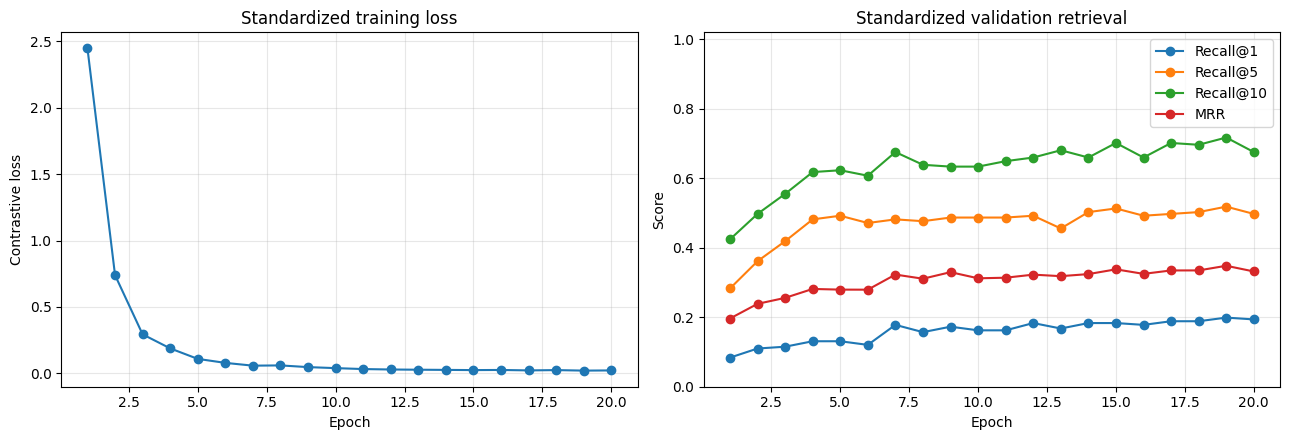

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o')
axes[0].set_title('Standardized training loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Contrastive loss')
axes[0].grid(True, alpha=0.3)

for metric in ['val_Recall@1', 'val_Recall@5', 'val_Recall@10', 'val_MRR']:
    if metric in history_df.columns:
        axes[1].plot(history_df['epoch'], history_df[metric], marker='o', label=metric.replace('val_', ''))
axes[1].set_title('Standardized validation retrieval')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.02)
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
curve_path = FIGURE_DIR / 'standardized_training_curves.png'
fig.savefig(curve_path, dpi=150, bbox_inches='tight')
print('Saved:', curve_path)
plt.show()

## 10. Evaluate standardized-trained model on CUFSF and FS2K

In [10]:
standardized_model = load_checkpoint(best_model_path)

std_test_metrics, std_test_ranks, std_test_similarity, _ = evaluate_retrieval_split(
    standardized_model, test_loader, 'Standardized-trained ResNet18 on CUFSF test'
)
std_fs2k_metrics, std_fs2k_ranks, std_fs2k_similarity, _ = evaluate_retrieval_split(
    standardized_model, fs2k_loader, 'Standardized-trained ResNet18 on FS2K OOD'
)

comparison = pd.DataFrame([
    {'experiment': 'previous_pipeline_cufsf_test', 'Recall@1': 0.271967, 'Recall@5': 0.564854, 'Recall@10': 0.677824, 'MRR': 0.406139, 'MedianRank': 4.0},
    {'experiment': 'previous_pipeline_fs2k_ood', 'Recall@1': 0.004278, 'Recall@5': 0.014734, 'Recall@10': 0.021388, 'MRR': 0.013157, 'MedianRank': 767.0},
    {'experiment': 'standardized_pipeline_cufsf_test', **std_test_metrics},
    {'experiment': 'standardized_pipeline_fs2k_ood', **std_fs2k_metrics},
])
comparison_csv = OUTPUT_DIR / 'standardized_vs_previous_results.csv'
comparison.to_csv(comparison_csv, index=False)
print('Saved:', comparison_csv)
display(comparison)

Loaded: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/models/best_resnet18_standardized_contrastive.pt
Checkpoint epoch: 19



Standardized-trained ResNet18 on CUFSF test
-------------------------------------------
Recall@1: 0.1590
Recall@5: 0.4477
Recall@10: 0.6360
MRR: 0.3131
MeanRank: 12.35
MedianRank: 6.00



Standardized-trained ResNet18 on FS2K OOD
-----------------------------------------
Recall@1: 0.0081
Recall@5: 0.0304
Recall@10: 0.0490
MRR: 0.0244
MeanRank: 640.96
MedianRank: 465.50
Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/standardized_vs_previous_results.csv


,experiment,Recall@1,Recall@5,Recall@10,MRR,MedianRank,MeanRank
0,previous_pipeline_cufsf_test,0.271967,0.564854,0.677824,0.406139,4.0,NaN
1,previous_pipeline_fs2k_ood,0.004278,0.014734,0.021388,0.013157,767.0,NaN
2,standardized_pipeline_cufsf_test,0.158996,0.447699,0.635983,0.313141,6.0,12.351464
3,standardized_pipeline_fs2k_ood,0.008080,0.030418,0.048954,0.024440,465.5,640.958650


## 11. Top-5 retrieval visualizations

Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/retrieval_examples/standardized_cufsf_test_top5.png


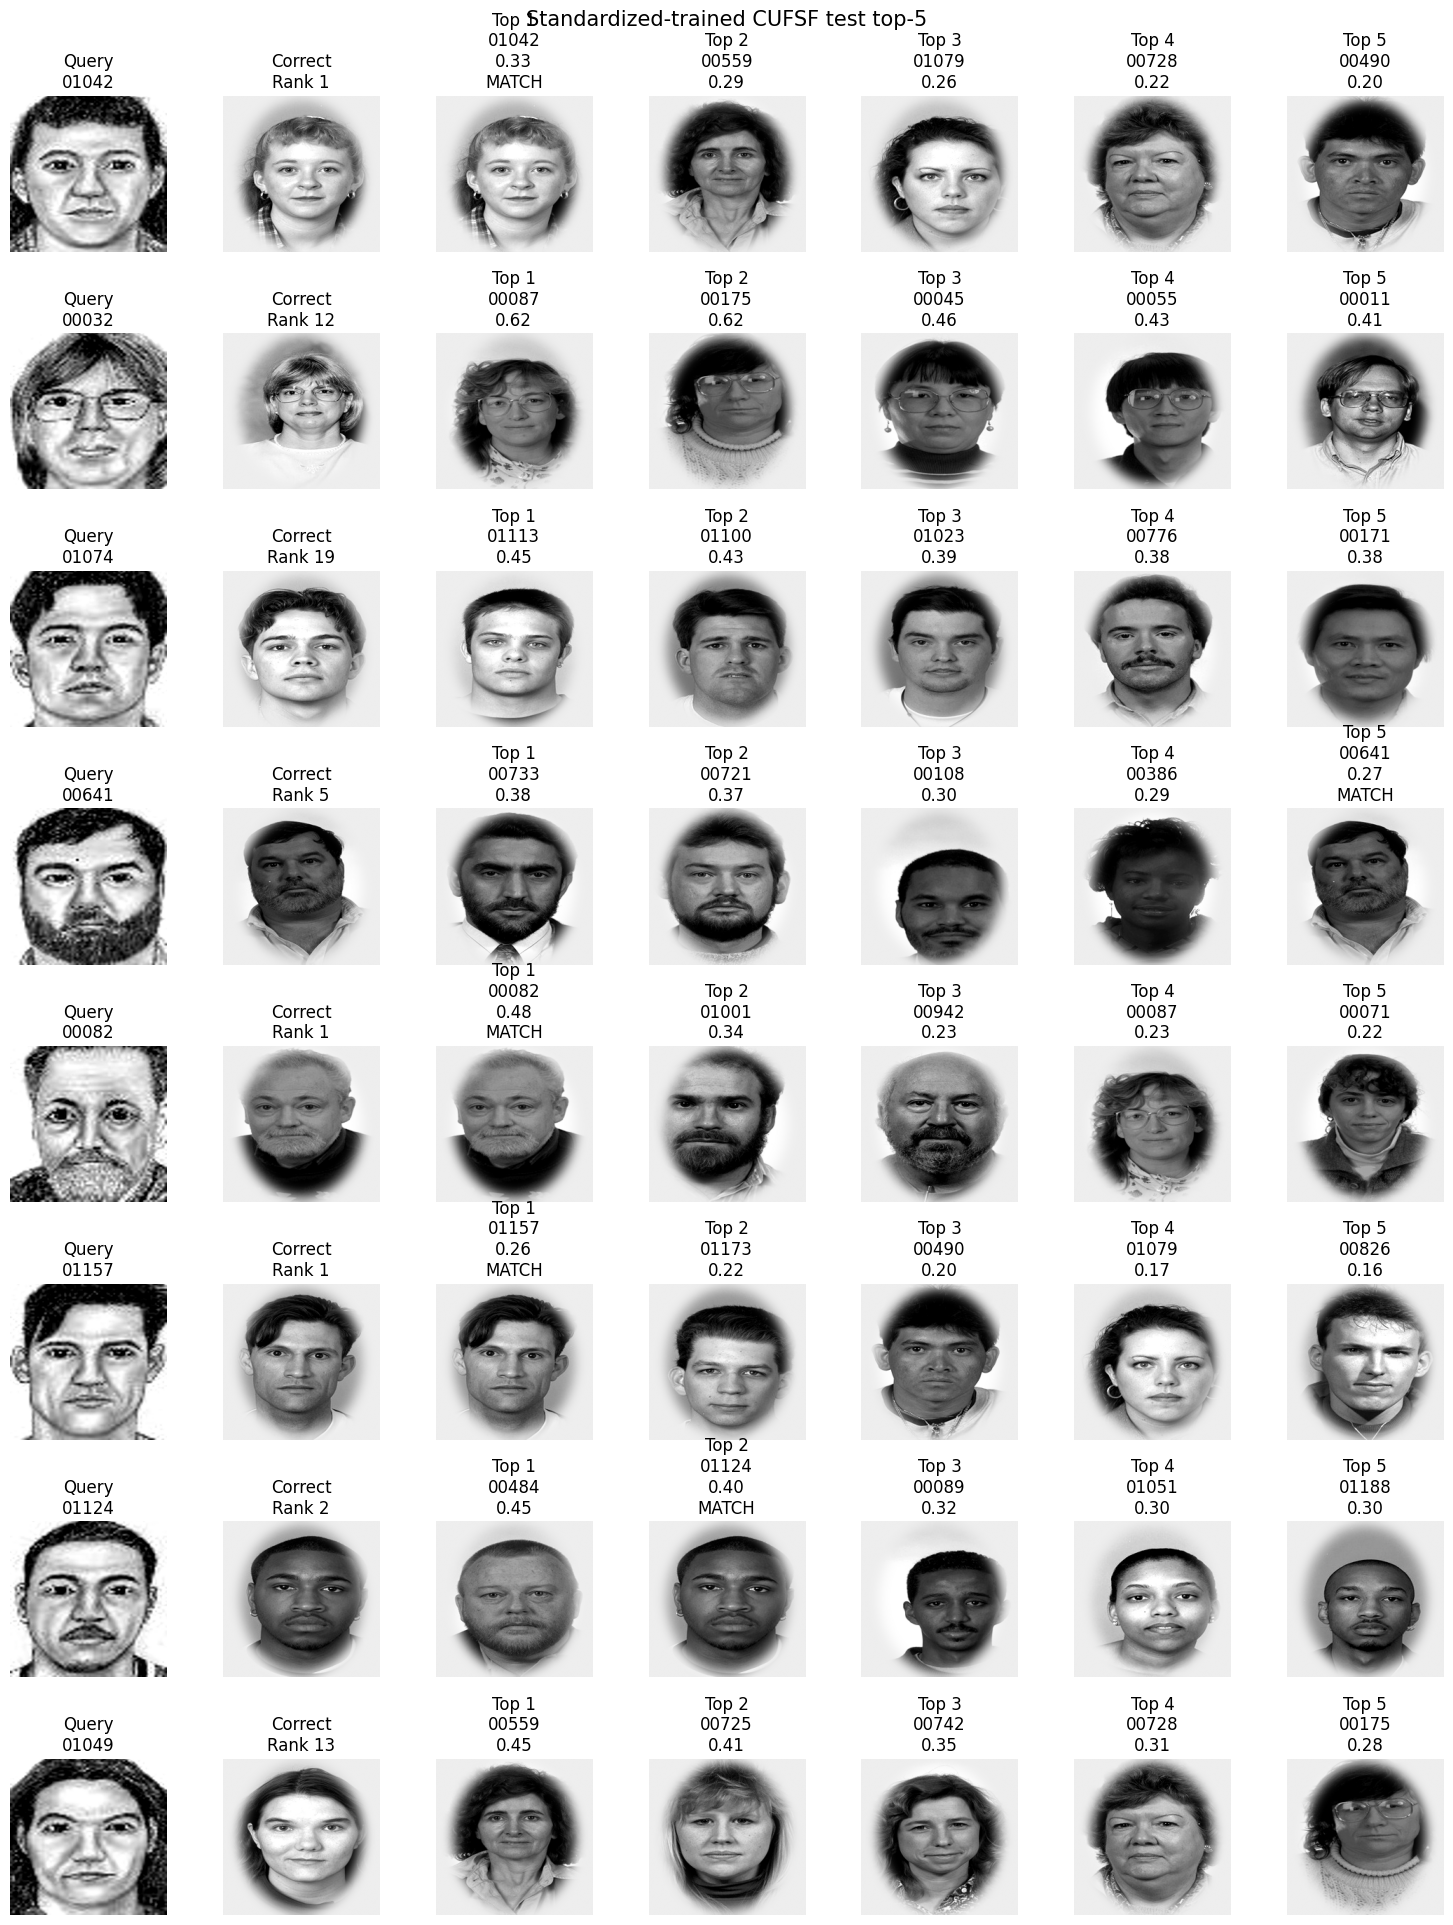

Saved: /home/tndor/Documents/Work/Classwork/semester-4/main-challenge/data/outputs/standardized_ingestion_ood/retrieval_examples/standardized_fs2k_ood_top5.png


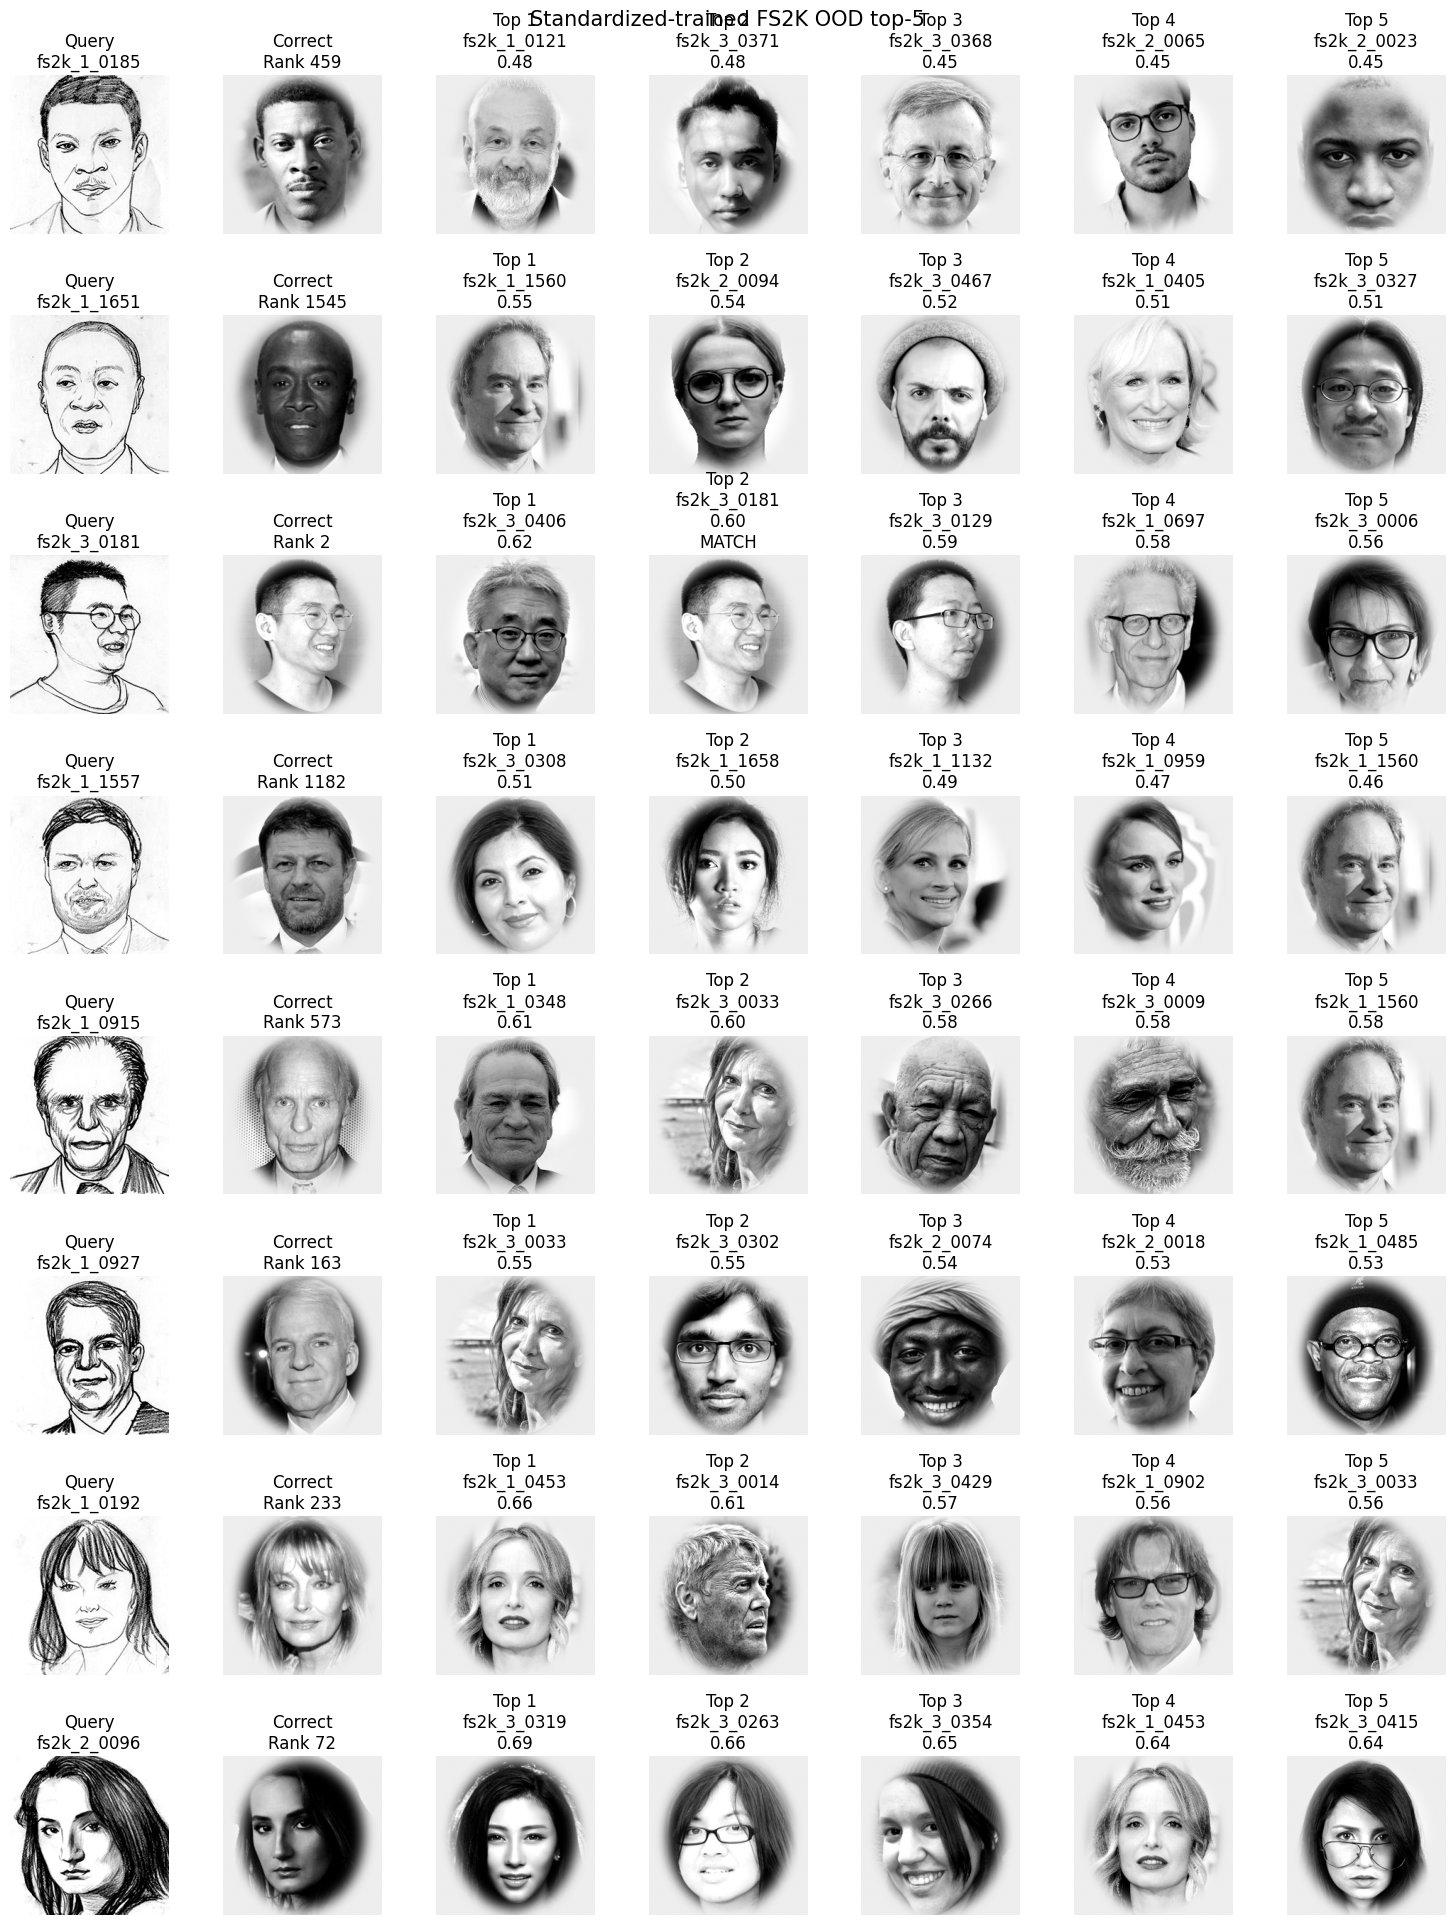

In [11]:
def make_retrieval_grid(df, similarity, ranks, method_name, n_examples=8, top_k=5, seed=42, save_path=None):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(df), size=min(n_examples, len(df)), replace=False)
    fig, axes = plt.subplots(len(indices), 2 + top_k, figsize=(2.15 * (2 + top_k), 2.45 * len(indices)))
    if len(indices) == 1:
        axes = np.array([axes])
    for row_i, query_idx in enumerate(indices):
        query = df.iloc[query_idx]
        ranked = np.argsort(-similarity[query_idx])[:top_k]
        axes[row_i, 0].imshow(Image.open(query['sketch_path']).convert('L'), cmap='gray', vmin=0, vmax=255)
        axes[row_i, 0].set_title(f"Query\n{query['id']}")
        axes[row_i, 0].axis('off')
        axes[row_i, 1].imshow(Image.open(query['photo_path']).convert('L'), cmap='gray', vmin=0, vmax=255)
        axes[row_i, 1].set_title(f"Correct\nRank {ranks[query_idx]}")
        axes[row_i, 1].axis('off')
        for j, gallery_idx in enumerate(ranked):
            item = df.iloc[gallery_idx]
            score = similarity[query_idx, gallery_idx]
            is_correct = str(item['id']) == str(query['id'])
            title = f"Top {j + 1}\n{item['id']}\n{score:.2f}"
            if is_correct:
                title += '\nMATCH'
            axes[row_i, 2 + j].imshow(Image.open(item['photo_path']).convert('L'), cmap='gray', vmin=0, vmax=255)
            axes[row_i, 2 + j].set_title(title)
            axes[row_i, 2 + j].axis('off')
    fig.suptitle(method_name, fontsize=15)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print('Saved:', save_path)
    plt.show()

make_retrieval_grid(
    std_test_df,
    std_test_similarity,
    std_test_ranks,
    'Standardized-trained CUFSF test top-5',
    save_path=RETRIEVAL_DIR / 'standardized_cufsf_test_top5.png',
)
make_retrieval_grid(
    std_fs2k_df,
    std_fs2k_similarity,
    std_fs2k_ranks,
    'Standardized-trained FS2K OOD top-5',
    save_path=RETRIEVAL_DIR / 'standardized_fs2k_ood_top5.png',
)